## Part 1 - Data Preprocessing

### Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

# device = torch.device('mps' if torch.mps.is_available() else 'cpu')
device = torch.device('cpu')

### Importing the training set

In [2]:
dataset_train = pd.read_csv('dataset/Google_Stock_Price_Train.csv')
training_set = dataset_train.iloc[:, 1:2].values

### Feature Scaling

In [3]:
sc = MinMaxScaler(feature_range = (0, 1))
training_set_scaled = sc.fit_transform(training_set)

### Creating a data structure with 60 timesteps and 1 output

In [4]:
X_train = []
y_train = []
for i in range(60, len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1) # shape: (N, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)

## Part 2 - Building and training the simple RNN and LSTM

### Building the Model Architecture

In [5]:
class SimpleRNNRegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=4, dropout=0.1):
        super(SimpleRNNRegressor, self).__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)
        out, _ = self.rnn(x)

        out = self.fc(out[:, -1, :])
        return out

class LSTMRegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=4, dropout=0.1):
        super(LSTMRegressor, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)
        self._init_weights()
        
    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param.data)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param.data)
            elif 'bias' in name:
                param.data.fill_(0)
                n = param.size(0)
                param.data[n//4:n//2].fill_(1.0)
                
        nn.init.xavier_uniform_(self.fc.weight)
        self.fc.bias.data.fill_(0)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out


### Training Loop

In [6]:
def train_model(model, train_loader, epochs=100, lr=0.001):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    model.train()
    loss_history = []
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item() * batch_X.size(0)
            
        total_epoch_loss = epoch_loss / len(train_loader.dataset)
        loss_history.append(total_epoch_loss)
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}] - Loss: {total_epoch_loss:.6f}")
            
    return loss_history

print("--- Training Simple RNN ---")
rnn_model = SimpleRNNRegressor(dropout=0.0).to(device)
rnn_loss_history = train_model(rnn_model, train_loader, epochs=200, lr=5*1e-4)

print("\n--- Training LSTM ---")
lstm_model = LSTMRegressor(dropout=0.0).to(device)
lstm_loss_history = train_model(lstm_model, train_loader, epochs=200, lr=5*1e-4)

--- Training Simple RNN ---
Epoch [1/200] - Loss: 0.093795
Epoch [10/200] - Loss: 0.000763
Epoch [20/200] - Loss: 0.000574
Epoch [30/200] - Loss: 0.000653
Epoch [40/200] - Loss: 0.000445
Epoch [50/200] - Loss: 0.000374
Epoch [60/200] - Loss: 0.000369
Epoch [70/200] - Loss: 0.000379
Epoch [80/200] - Loss: 0.000301
Epoch [90/200] - Loss: 0.000357
Epoch [100/200] - Loss: 0.000382
Epoch [110/200] - Loss: 0.000300
Epoch [120/200] - Loss: 0.000323
Epoch [130/200] - Loss: 0.000339
Epoch [140/200] - Loss: 0.000280
Epoch [150/200] - Loss: 0.000286
Epoch [160/200] - Loss: 0.000314
Epoch [170/200] - Loss: 0.000284
Epoch [180/200] - Loss: 0.000282
Epoch [190/200] - Loss: 0.000323
Epoch [200/200] - Loss: 0.000311

--- Training LSTM ---
Epoch [1/200] - Loss: 0.049927
Epoch [10/200] - Loss: 0.003791
Epoch [20/200] - Loss: 0.002559
Epoch [30/200] - Loss: 0.001850
Epoch [40/200] - Loss: 0.001935
Epoch [50/200] - Loss: 0.001529
Epoch [60/200] - Loss: 0.001363
Epoch [70/200] - Loss: 0.001309
Epoch [80/20

## Part 3 - Making the predictions and visualising the results

### Making the predictions and visualising the results

In [7]:
dataset_test = pd.read_csv('dataset/Google_Stock_Price_Test.csv')
real_stock_price = dataset_test.iloc[:, 1:2].values

dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), axis=0)
inputs = dataset_total[len(dataset_total) - len(dataset_test) - 60:].values
inputs = inputs.reshape(-1, 1)
inputs = sc.transform(inputs)

X_test = []
for i in range(60, 60 + len(dataset_test)):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

rnn_model.eval()
with torch.no_grad():
    predicted_rnn = rnn_model(X_test_tensor).cpu().numpy()
predicted_rnn = sc.inverse_transform(predicted_rnn)

lstm_model.eval()
with torch.no_grad():
    predicted_lstm = lstm_model(X_test_tensor).cpu().numpy()
predicted_lstm = sc.inverse_transform(predicted_lstm)

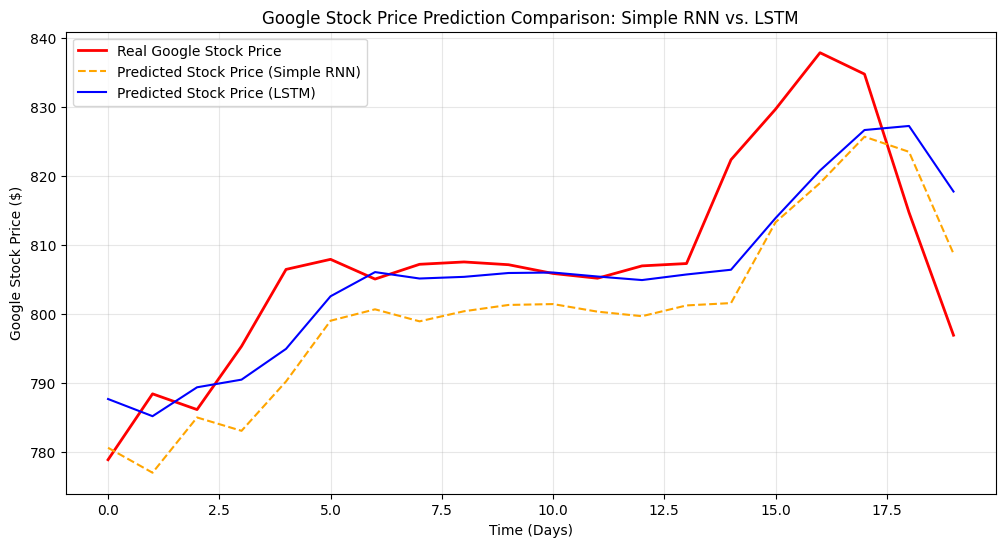

In [8]:
plt.figure(figsize=(12, 6))

plt.plot(real_stock_price, color='red', label='Real Google Stock Price', linewidth=2)

plt.plot(predicted_rnn, color='orange', linestyle='--', label='Predicted Stock Price (Simple RNN)')

plt.plot(predicted_lstm, color='blue', label='Predicted Stock Price (LSTM)')

plt.title('Google Stock Price Prediction Comparison: Simple RNN vs. LSTM')
plt.xlabel('Time (Days)')
plt.ylabel('Google Stock Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()